tabii—adım adım gidelim. (Aşağıdaki açıklamalar **KNN, SVM (linear), Kernel SVM (RBF) ve Random Forest**’ı tek bir çatı altında, **Pipeline + GridSearchCV** ile denediğimiz akışa göredir.)

# 1) Problemi tanımla

* **Amaç:** “diagnosis” (B/M) sınıfını tahmin etmek (ikili sınıflandırma).
* **Neden farklı modeller?** Veriye en iyi uyanı seçmek için KNN / SVM / RBF-SVM / RF’yi kıyaslayacağız.

# 2) Veriyi oku ve düzenle

* Gereksiz sütunları at: `id`, `Unnamed: 32` vb.
* **Hedefi sayısallaştır:** `diagnosis` → `{"B":0, "M":1}`
* Özellik matrisi **X**, hedef **y**:

  ```python
  y = df["diagnosis"].map({"B":0, "M":1}).astype(int)
  X = df.drop(columns=["diagnosis"])
  ```

# 3) Train/Test ayır (leakage’i engelle)

* Dengesiz sınıflar için **stratify** şart:

  ```python
  X_train, X_test, y_train, y_test = train_test_split(
      X, y, test_size=0.2, random_state=42, stratify=y
  )
  ```

# 4) Data leakage nedir?

* Eğitim dışı (test/CV) bilgiyi eğitim aşamasına sızdırmaktır.
* Ölçekleme/İmpute işlemleri **sadece train** üzerinde fit edilmeli. Bunu **Pipeline** otomatik garanti eder.

# 5) Pipeline nedir? (Yeni mi?)

* **Pipeline**, bir dizi **dönüşüm (impute/scale/encode)** ve **modeli** zincirleyip, tek bir estimator gibi kullandırır.
* Uzun zamandır scikit-learn’da var; “yeni” değil. Ama **doğru CV** ve **leakage’ı önlemek** için endüstride standarttır.
* Örnek iskelet:

  ```python
  pipe = Pipeline([
      ("imputer", SimpleImputer(strategy="median")),
      ("scaler", StandardScaler()),
      ("model", SVC(kernel="rbf", probability=True))
  ])
  ```

  > Not: RF ölçeklemeye muhtaç değil ama aynı şablonda kalması **zararsız** ve pratik.

# 6) Neden bu adımlar?

* **Imputer**: Eksikleri doldurur (sayısalda `median`/`mean`).
* **Scaler**: KNN/SVM gibi **mesafeye/ölçeğe duyarlı** algoritmalar için kritik.
* **Model**: KNN / Linear SVM / RBF-SVM / RF.

# 7) GridSearchCV (hiperparametre araması)

* Farklı model + parametre kombinasyonlarını **K-fold CV** ile dener, seçtiğin bir skora göre en iyiyi bulur.
* **StratifiedKFold** kullan: sınıf oranlarını her fold’da korur.
* Birden çok skor takip edip (accuracy, precision, recall, f1, roc\_auc), **`refit='f1'`** ile en iyi modeli **F1**’e göre yeniden eğitebilirsin.
* Kısa örnek:

  ```python
  scoring = {"accuracy":"accuracy","precision":"precision",
             "recall":"recall","f1":"f1","roc_auc":"roc_auc"}
  cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

  gs = GridSearchCV(pipe, param_grid=param_grid, scoring=scoring,
                    refit="f1", cv=cv, n_jobs=-1)
  gs.fit(X_train, y_train)
  best_model = gs.best_estimator_
  ```

# 8) Modeller ve önemli hiperparametreler

* **KNN**: `n_neighbors` (k), `weights` (uniform/distance), `p` (1=Manhattan, 2=Euclidean).
* **SVM (linear)**: `C` (düzenlileştirme). Büyük **C** → daha katı uyum.
* **Kernel SVM (RBF)**: `C` + `gamma` (sınırın kıvrımı; büyük gamma daha karmaşık sınır).
* **Random Forest**: `n_estimators`, `max_depth`, `min_samples_split`, `max_features`. (Ölçeklemeden etkilenmez.)

# 9) Eğitim ve tahmin

* `best_model.predict(X_test)` ile sınıf,
* `best_model.predict_proba(X_test)[:,1]` ile **olasılık** (SVM için `probability=True` Platt scaling yapar; biraz yavaşlatır ama ROC-AUC için gerekir).

# 10) Değerlendirme metrikleri

* **Accuracy**: Genel doğruluk; sınıf dengesizse tek başına yeterli değil.
* **Precision**: “Pozitif dediklerinin” ne kadarı doğru?
* **Recall (duyarlılık)**: Gerçek pozitifleri yakalama oranı. Kanser taramasında kritik.
* **F1**: Precision & Recall’un harmonik ortalaması; dengesizlikte iyi bir özet.
* **ROC-AUC**: Eşik bağımsız ayrıştırma gücü; **yüksek → iyi**.
* **Confusion Matrix** ve **classification\_report** ile ayrıntı.

# 11) ROC eğrisi ve eşik ayarı (opsiyonel ama değerli)

* Default eşik 0.5’tir; **F1** veya **Recall**’ı maksimize eden **eşik** farklı olabilir.
* PR-curve/ROC-curve üzerinden **iş hedefine** göre eşik seçimi profesyonel uygulamalarda yaygındır.

# 12) Dengesizlik ipuçları

* Sınıf oranları bozuksa:

  * `class_weight='balanced'` (SVM),
  * veri artırma (SMOTE),
  * **recall/F1/ROC-AUC** odaklı seçim,
  * eşik (threshold) optimizasyonu.

# 13) Model yorumlanabilirliği (kısa)

* **Linear SVM**: `coef_` ile özellik etkisi (ölçek sonrasında).
* **RF**: `feature_importances_` ile önem puanları (permutation importance daha güvenilir).
* **KNN & RBF-SVM**: katsayı temelli yorum sınırlı; SHAP/Permutation ile incelenebilir.

# 14) Sık yapılan hatalar

* **Scaler’ı/Imputer’ı** tüm veri üzerinde fit etmek → **leakage**. Pipeline/CV ile çöz.
* SVM/KNN’de **ölçeklemeyi unutmak** → performans düşer.
* Tek metrikle karar vermek (sadece accuracy) → dengesiz veri tuzağı.
* CV’siz parametre seçmek → **aşırı uyum** riski.

---

## Mini kod özeti (çok kısa, mevcut yapını hatırlatmak için)

```python
def make_pipe(estimator):
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", estimator)
    ])

candidates = [
    ("KNN", make_pipe(KNeighborsClassifier()),
     {"model__n_neighbors":[3,5,7,9], "model__weights":["uniform","distance"], "model__p":[1,2]}),

    ("SVM-linear", make_pipe(SVC(kernel="linear", probability=True)),
     {"model__C":[0.1,1,10], "model__class_weight":[None,"balanced"]}),

    ("SVM-RBF", make_pipe(SVC(kernel="rbf", probability=True)),
     {"model__C":[0.1,1,10], "model__gamma":["scale",0.01,0.1,1], "model__class_weight":[None,"balanced"]}),

    ("RF", make_pipe(RandomForestClassifier(random_state=42, n_jobs=-1)),
     {"model__n_estimators":[200,400], "model__max_depth":[None,10,20], "model__max_features":["sqrt","log2",None]})
]

for name, pipe, grid in candidates:
    gs = GridSearchCV(pipe, grid, scoring={"f1":"f1","roc_auc":"roc_auc"},
                      refit="f1", cv=StratifiedKFold(5,shuffle=True,random_state=42),
                      n_jobs=-1)
    gs.fit(X_train, y_train)
    print(name, "best:", gs.best_params_)
```

---

### “Pipeline yeni mi?” kısa cevap

* **Hayır, yeni değil.** scikit-learn’da uzun süredir var.
* Ama **doğru kullanım** (özellikle CV ile) eğitimlerde genellikle **daha ileri bölümlerde** anlatılır.
* Pratikte **leakage’ı otomatik engellediği** ve **deneyleri tekrar edilebilir kıldığı** için **her projede** kullanmanı öneririm.

> İstersen aynı iskelete **Precision-Recall eğrisi**, **eşik optimizasyonu** veya **özellik önemi (RF/Permutation)** bloklarını da ekleyeyim; hangi metrik/hedefe ağırlık vermek istediğini söylemen yeterli.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay,
    classification_report
)

In [2]:
# ===============================
# 1) VERİ
# ===============================
df = pd.read_csv("bcwdata.csv")

In [3]:
# Sık görülen gereksiz kolonlar: 'id', 'Unnamed: 32' (varsa at)
drop_cols = [c for c in ["id", "ID", "Unnamed: 32"] if c in df.columns]
df = df.drop(columns=drop_cols)

In [4]:
# Hedef: diagnosis (B/M) -> 0/1 (B=0, M=1)
y = df["diagnosis"].map({"B": 0, "M": 1}).astype(int)
X = df.drop(columns=["diagnosis"])

In [5]:
# ===============================
# 2) TRAIN/TEST (stratify önemli)
# ===============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

In [6]:
# ===============================
# 3) MODEL PIPELINE'LARI
# - Impute (gerekirse), Scale (KNN/SVM için kritik), Model
# - RF için scaler zararsızdır, pipeline birlik sağlar.
# ===============================
def make_pipe(estimator):
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", estimator)
    ])

models_and_grids = [
    (
        "KNN",
        make_pipe(KNeighborsClassifier()),
        {
            "model__n_neighbors": [3, 5, 7, 9, 11, 15, 21],
            "model__weights": ["uniform", "distance"],
            "model__p": [1, 2],  # 1: Manhattan, 2: Euclidean
        }
    ),
    (
        "SVM (Linear)",
        make_pipe(SVC(kernel="linear", probability=True, class_weight=None)),
        {
            "model__C": [0.1, 1, 10, 100],
            "model__class_weight": [None, "balanced"]
        }
    ),
    (
        "SVM (RBF)",
        make_pipe(SVC(kernel="rbf", probability=True, class_weight=None)),
        {
            "model__C": [0.1, 1, 10, 100],
            "model__gamma": ["scale", 0.01, 0.1, 1],
            "model__class_weight": [None, "balanced"]
        }
    ),
    (
        "RandomForest",
        make_pipe(RandomForestClassifier(random_state=42, n_jobs=-1)),
        {
            "model__n_estimators": [200, 400, 800],
            "model__max_depth": [None, 5, 10, 20],
            "model__min_samples_split": [2, 5, 10],
            "model__max_features": ["sqrt", "log2", None]
        }
    ),
]

In [7]:
# ===============================
# 4) GRIDSEARCHCV AYARLARI
# - Birden çok skor takip ediyoruz; refit='f1'
# ===============================
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = []
best_overall = {"name": None, "estimator": None, "f1": -1}

for name, pipe, grid in models_and_grids:
    gs = GridSearchCV(
        estimator=pipe,
        param_grid=grid,
        scoring=scoring,
        refit="f1",     # en iyi modeli F1'a göre seç
        cv=cv,
        n_jobs=-1,
        verbose=0
    )
    gs.fit(X_train, y_train)

    # En iyi estimator ve CV skorları
    best_est = gs.best_estimator_
    cv_scores = gs.cv_results_
    print(f"\n{name} -> En iyi parametreler: {gs.best_params_}")

    # Test setinde ölç
    y_pred = best_est.predict(X_test)
    y_proba = best_est.predict_proba(X_test)[:, 1]

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec  = recall_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred)
    auc_ = roc_auc_score(y_test, y_proba)

    print(f"{name} Test -> Acc: {acc:.3f} | Prec: {prec:.3f} | Rec: {rec:.3f} | F1: {f1:.3f} | AUC: {auc_:.3f}")

    results.append({
        "model": name, "accuracy": acc, "precision": prec,
        "recall": rec, "f1": f1, "roc_auc": auc_
    })

    if f1 > best_overall["f1"]:
        best_overall = {"name": name, "estimator": best_est, "f1": f1}


KNN -> En iyi parametreler: {'model__n_neighbors': 3, 'model__p': 1, 'model__weights': 'uniform'}
KNN Test -> Acc: 0.965 | Prec: 1.000 | Rec: 0.905 | F1: 0.950 | AUC: 0.974

SVM (Linear) -> En iyi parametreler: {'model__C': 0.1, 'model__class_weight': None}
SVM (Linear) Test -> Acc: 0.982 | Prec: 1.000 | Rec: 0.952 | F1: 0.976 | AUC: 0.996

SVM (RBF) -> En iyi parametreler: {'model__C': 10, 'model__class_weight': 'balanced', 'model__gamma': 0.01}
SVM (RBF) Test -> Acc: 0.991 | Prec: 1.000 | Rec: 0.976 | F1: 0.988 | AUC: 0.997

RandomForest -> En iyi parametreler: {'model__max_depth': 10, 'model__max_features': 'log2', 'model__min_samples_split': 2, 'model__n_estimators': 200}
RandomForest Test -> Acc: 0.956 | Prec: 1.000 | Rec: 0.881 | F1: 0.937 | AUC: 0.994


In [8]:
# ===============================
# 5) KARŞILAŞTIRMA TABLOSU
# ===============================
res_df = pd.DataFrame(results).sort_values(["f1", "roc_auc", "accuracy"], ascending=False)
print("\n=== Model Karşılaştırma (önce F1, sonra AUC/Accuracy) ===")
print(res_df.to_string(index=False))

print(f"\nEn iyi model (F1'a göre): {best_overall['name']}")


=== Model Karşılaştırma (önce F1, sonra AUC/Accuracy) ===
       model  accuracy  precision   recall       f1  roc_auc
   SVM (RBF)  0.991228        1.0 0.976190 0.987952 0.997024
SVM (Linear)  0.982456        1.0 0.952381 0.975610 0.996362
         KNN  0.964912        1.0 0.904762 0.950000 0.973545
RandomForest  0.956140        1.0 0.880952 0.936709 0.994213

En iyi model (F1'a göre): SVM (RBF)


In [9]:
# ===============================
# 6) EN İYİ MODEL İÇİN CM + ROC EĞRİSİ
# ===============================
best = best_overall["estimator"]
y_pred_best = best.predict(X_test)
y_proba_best = best.predict_proba(X_test)[:, 1]

In [10]:
# Classification report
print("\nClassification report (best model):\n",
      classification_report(y_test, y_pred_best, target_names=["B", "M"]))


Classification report (best model):
               precision    recall  f1-score   support

           B       0.99      1.00      0.99        72
           M       1.00      0.98      0.99        42

    accuracy                           0.99       114
   macro avg       0.99      0.99      0.99       114
weighted avg       0.99      0.99      0.99       114



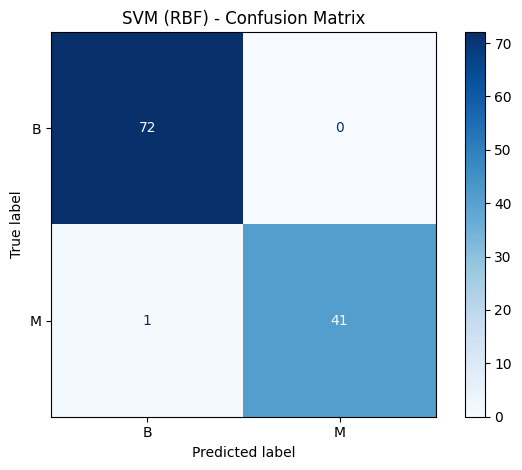

In [11]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best, labels=[0, 1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["B", "M"])
disp.plot(cmap="Blues", values_format="d")
plt.title(f"{best_overall['name']} - Confusion Matrix")
plt.tight_layout()
plt.show()

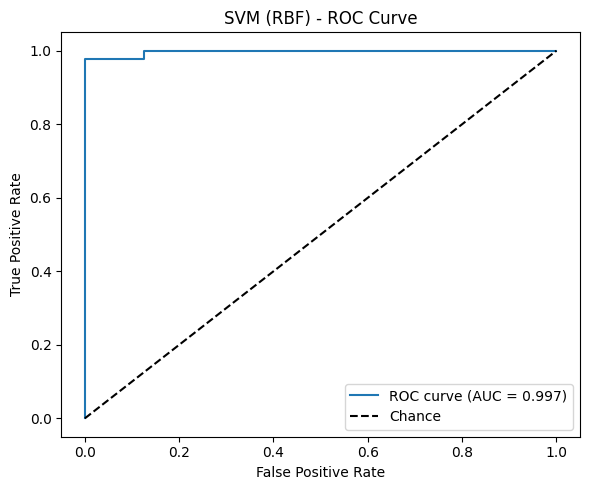

In [12]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba_best)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], "k--", label="Chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"{best_overall['name']} - ROC Curve")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()